# Controlled Addition

In [3]:
from qualtran import Bloq, CompositeBloq, BloqBuilder, Signature, Register
from qualtran import QBit, QInt, QUInt, QAny
from qualtran.drawing import show_bloq, show_call_graph, show_counts_sigma
from typing import *
import numpy as np
import sympy
import cirq
from experiments.helper_functions import *
# import experiments.helper_functions 

## `CAdd`
An n-bit controlled-addition gate.

This uses $n$ `And` gates plus an uncontrolled adder for a total of $2n - 1$ Toffolis.

#### Parameters
 - `a_dtype`: Quantum datatype used to represent the integer a.
 - `b_dtype`: Quantum datatype used to represent the integer b. Must be large enough to hold the result in the output register of a + b, or else it simply drops the most significant bits. If not specified, b_dtype is set to a_dtype.
 - `cv`: When controlled=0, this bloq is active when the ctrl register is 0. When controlled=1, this bloq is active when the ctrl register is 1. 

#### Registers
 - `ctrl`: the control bit for the addition
 - `a`: A a_dtype.bitsize-sized input register (register a above).
 - `b`: A b_dtype.bitsize-sized input/output register (register b above). 

#### References
 - [Halving the cost of quantum addition](https://arxiv.org/abs/1709.06648). 


In [4]:
from qualtran.bloqs.arithmetic import CAdd

### Example Instances

In [5]:
cadd_small = CAdd(QUInt(3))

In [6]:
cadd_large = CAdd(QUInt(1000), QUInt(1000))

#### Graphical Signature

False
CircuitDag with 19 nodes and 160 edges


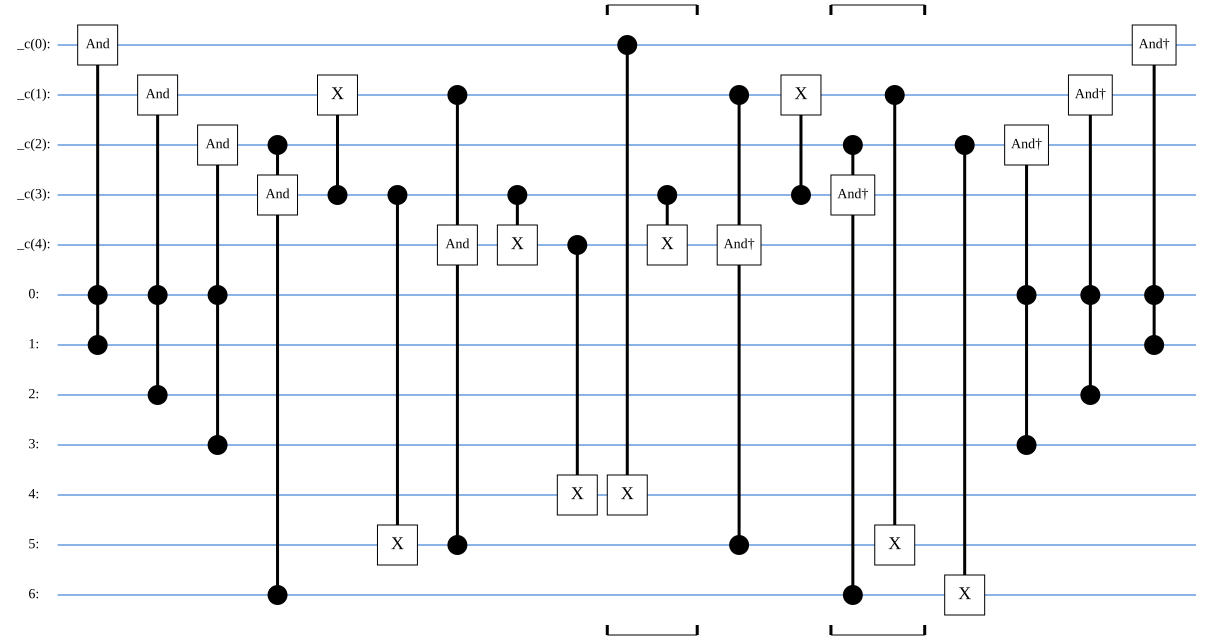

In [7]:
from qualtran.drawing import show_bloqs
# show_bloqs([cadd_small, cadd_large],
#            ['`cadd_small`', '`cadd_large`'])
# show_bloq(cadd_small.decompose_bloq())
# print(cadd_small.signature)
# create_register_dict_from_signature(cadd_small.signature)
# quregs_list = {}
# for i in range(len(cadd_small.signature)):
#     print(cadd_small.signature[i].name)
#     print(cadd_small.signature[i].dtype)
#     print(cadd_small.signature[i].dtype.num_qubits)
#     quregs_list[cadd_small.signature[i].name] = cirq.LineQubit.range(3)

register_list = create_register_dict_from_signature(cadd_small.signature)
# print(register_list)

print(isinstance(cadd_small, CompositeBloq))


# print("no flatten:")
# for instance in cadd_small.decompose_bloq().bloq_instances:
#     print(instance)

    
# for instance in cadd_small.decompose_bloq().bloq_instances:
#     print(instance)
circuit = cadd_small.as_composite_bloq().flatten().to_cirq_circuit(
    cirq_quregs= register_list
)


# decompose_once_op = cirq.decompose_once(op)
# for op in circuit.all_operations():
#     # 'op' is a cirq.Operation, like cirq.CNOT(q0, q1)
#     print(f"Processing operation: {op}")

# # print(circuit.all_qubits())

# for qubits in circuit.all_qubits():
#     print(qubits)

op = circuit.all_operations()
cadd_circuit = cirq.Circuit(op)


# turn the  circuit into a digraph
from cirq.contrib import CircuitDag
from networkx.drawing import nx_pydot

circuit_dag = CircuitDag.from_circuit(cadd_circuit)
print(circuit_dag)
# draw the circuit_dag using networkx
# circuit_dag is a networkx directed graph
# save the circuit_dag as a dot file
# nx_pydot.write_dot(circuit_dag, "circuit_dag.dot")
# print the nodes that have no incoming edges

# draw the circuit
from cirq.contrib.svg import SVGCircuit
SVGCircuit(cadd_circuit)




In [8]:

# turn the circuit into a dag and store it into a .dot file
digraph = nx.DiGraph()

# count the current nodes in the digraph
node_index = 0

cur_nodes_positions = {}
qubits_indices = {}
# add the qqubits to the digraph
for qubit in cadd_circuit.all_qubits():
    # is_ancillary = qubit.is_ancillary()
    print(qubit , str(qubit).startswith('_'))
    digraph.add_node(node_index, label=str(qubit), qubits = str(node_index), matrix="None", ancilla=str(qubit).startswith('_'))
    cur_nodes_positions[str(qubit)] = node_index
    qubits_indices[str(qubit)] = node_index
    node_index += 1

# add the operations to the digraph
for op in cadd_circuit.all_operations():
    # parse the qubits interact with the operation
    # turn this And(q(0), q(1), _c(0)) into a list ['q(0)', 'q(1)', '_c(0)']
    qubits_str = str(op) # And(q(0), q(1), _c(0))
    # remove the substring before the first '(' and after the last ')' and preseve all the characters in between    
    qubits_str = qubits_str[qubits_str.find('(')+1:qubits_str.rfind(')')]
    # remove the space in the qubits_str
    qubits_str = qubits_str.replace(' ', '')
    # split the qubits_str by ', '
    qubits = qubits_str.split(',')
    print(qubits)
    
    label = str(op)
    matrix = "None"
    if op.gate == cirq.CNOT or str(op.gate) == "And" or str(op.gate) == "And†":
        matrix = "[[0, 1], [1, 0]]"
    num_qubits = len(qubits)
    num_clbits=0
    qubits_list = []
    for qubit in qubits:
        qubits_list.append(qubits_indices[str(qubit)])

    # turn the qubits_list into a string
    qubits_list_str = ','.join(str(qubit) for qubit in qubits_list)
    
    # add the operation as a node to the digraph
    digraph.add_node(node_index, label=label, qubits = qubits_list_str, matrix=matrix)
    print(f"add node: label={label}, qubits={qubits_list_str}, matrix={matrix}")
    cur_operation_node = node_index
    node_index += 1

    # add the edges to this operation
    for qubit in qubits:
        digraph.add_edge(cur_nodes_positions[qubit], cur_operation_node, label=str(qubits_indices[str(qubit)]))
        print(f"add edge: {cur_nodes_positions[qubit]} -> {cur_operation_node}")
        # update the current node position for this qubit
        cur_nodes_positions[qubit] = cur_operation_node

# connect all the operation nodes to the output node
for index, node in enumerate(qubits_indices):
    print("output node: ", node, index)
    digraph.add_node(node_index, label=str(node), qubits = str(index), matrix="None", ancilla=str(node).startswith('_'))
    cur_output_node = node_index
    node_index += 1

    digraph.add_edge(cur_nodes_positions[node], cur_output_node, label=str(index))
    print(f"add edge: {cur_nodes_positions[node]} -> {cur_output_node}")
    

    # print(op, op.qubits, op.gate, op.gate == cirq.CNOT or str(op.gate) == "And" or str(op.gate) == "And†")
    # add the operation to the digraph

# save the digraph as a dot file
nx_pydot.write_dot(digraph, "digraph.dot")

q(6) False
q(1) False
_c(1) True
_c(0) True
q(4) False
q(0) False
q(5) False
_c(4) True
q(2) False
q(3) False
_c(2) True
_c(3) True
['q(0)', 'q(1)', '_c(0)']
add node: label=And(q(0), q(1), _c(0)), qubits=5,1,3, matrix=[[0, 1], [1, 0]]
add edge: 5 -> 12
add edge: 1 -> 12
add edge: 3 -> 12
['q(0)', 'q(2)', '_c(1)']
add node: label=And(q(0), q(2), _c(1)), qubits=5,8,2, matrix=[[0, 1], [1, 0]]
add edge: 12 -> 13
add edge: 8 -> 13
add edge: 2 -> 13
['q(0)', 'q(3)', '_c(2)']
add node: label=And(q(0), q(3), _c(2)), qubits=5,9,10, matrix=[[0, 1], [1, 0]]
add edge: 13 -> 14
add edge: 9 -> 14
add edge: 10 -> 14
['_c(2)', 'q(6)', '_c(3)']
add node: label=And(_c(2), q(6), _c(3)), qubits=10,0,11, matrix=[[0, 1], [1, 0]]
add edge: 14 -> 15
add edge: 0 -> 15
add edge: 11 -> 15
['_c(3)', '_c(1)']
add node: label=CNOT(_c(3), _c(1)), qubits=11,2, matrix=[[0, 1], [1, 0]]
add edge: 15 -> 16
add edge: 13 -> 16
['_c(3)', 'q(5)']
add node: label=CNOT(_c(3), q(5)), qubits=11,6, matrix=[[0, 1], [1, 0]]
add ed

In [11]:
create_digraph_from_circuit(cadd_circuit)
save_digraph_to_dot(digraph, "cadd_circuit.dot")

q(6) False
q(1) False
_c(1) True
_c(0) True
q(4) False
q(0) False
q(5) False
_c(4) True
q(2) False
q(3) False
_c(2) True
_c(3) True
['q(0)', 'q(1)', '_c(0)']
add node: label=And(q(0), q(1), _c(0)), qubits=5,1,3, matrix=[[0, 1], [1, 0]]
add edge: 5 -> 12
add edge: 1 -> 12
add edge: 3 -> 12
['q(0)', 'q(2)', '_c(1)']
add node: label=And(q(0), q(2), _c(1)), qubits=5,8,2, matrix=[[0, 1], [1, 0]]
add edge: 12 -> 13
add edge: 8 -> 13
add edge: 2 -> 13
['q(0)', 'q(3)', '_c(2)']
add node: label=And(q(0), q(3), _c(2)), qubits=5,9,10, matrix=[[0, 1], [1, 0]]
add edge: 13 -> 14
add edge: 9 -> 14
add edge: 10 -> 14
['_c(2)', 'q(6)', '_c(3)']
add node: label=And(_c(2), q(6), _c(3)), qubits=10,0,11, matrix=[[0, 1], [1, 0]]
add edge: 14 -> 15
add edge: 0 -> 15
add edge: 11 -> 15
['_c(3)', '_c(1)']
add node: label=CNOT(_c(3), _c(1)), qubits=11,2, matrix=[[0, 1], [1, 0]]
add edge: 15 -> 16
add edge: 13 -> 16
['_c(3)', 'q(5)']
add node: label=CNOT(_c(3), q(5)), qubits=11,6, matrix=[[0, 1], [1, 0]]
add ed

### Call Graph

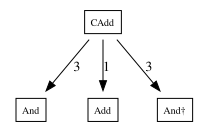

#### Counts totals:
 - `Add`: 1
 - `And`: 3
 - `And†`: 3

In [10]:
from qualtran.resource_counting.generalizers import ignore_split_join
cadd_small_g, cadd_small_sigma = cadd_small.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(cadd_small_g)
show_counts_sigma(cadd_small_sigma)